In [39]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight

In [25]:
#read in data
netflix_data = pd.read_csv('/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/netflix_user_behavior_dataset.csv')
netflix_data.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


The dataset, created by Kaggle user @rhythmghai, contains synthetic user-level data representing viewing behavior on a streaming platform similar to Netflix. Each row corresponds to one user and includes demographic attributes (e.g., age, location), subscription details, device usage patterns, and engagement metrics such as watch time and content interaction frequency. There are 50,000 users total with 20 columns, two of which correspond to a user’s ID and churn status (Yes, No).

## EDA

In [3]:
# check number of rows and columns
netflix_data.shape

(50000, 20)

In [4]:
# check data types
netflix_data.dtypes

user_id                          str
age                            int64
gender                           str
country                          str
account_age_months             int64
subscription_type                str
monthly_fee                  float64
payment_method                   str
primary_device                   str
devices_used                   int64
favorite_genre                   str
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                          str
dtype: object

In [5]:
#check for missing values
netflix_data.isna().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

In [6]:
#check for duplicates
netflix_data.duplicated().sum()

np.int64(0)

Overall, there are 12 quantitative variables and 8 categorical variables (including user ID and churn status) in the dataset. There are no missing values for any of the variables.

In [7]:
#quantitative variables summary statistics
netflix_data.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


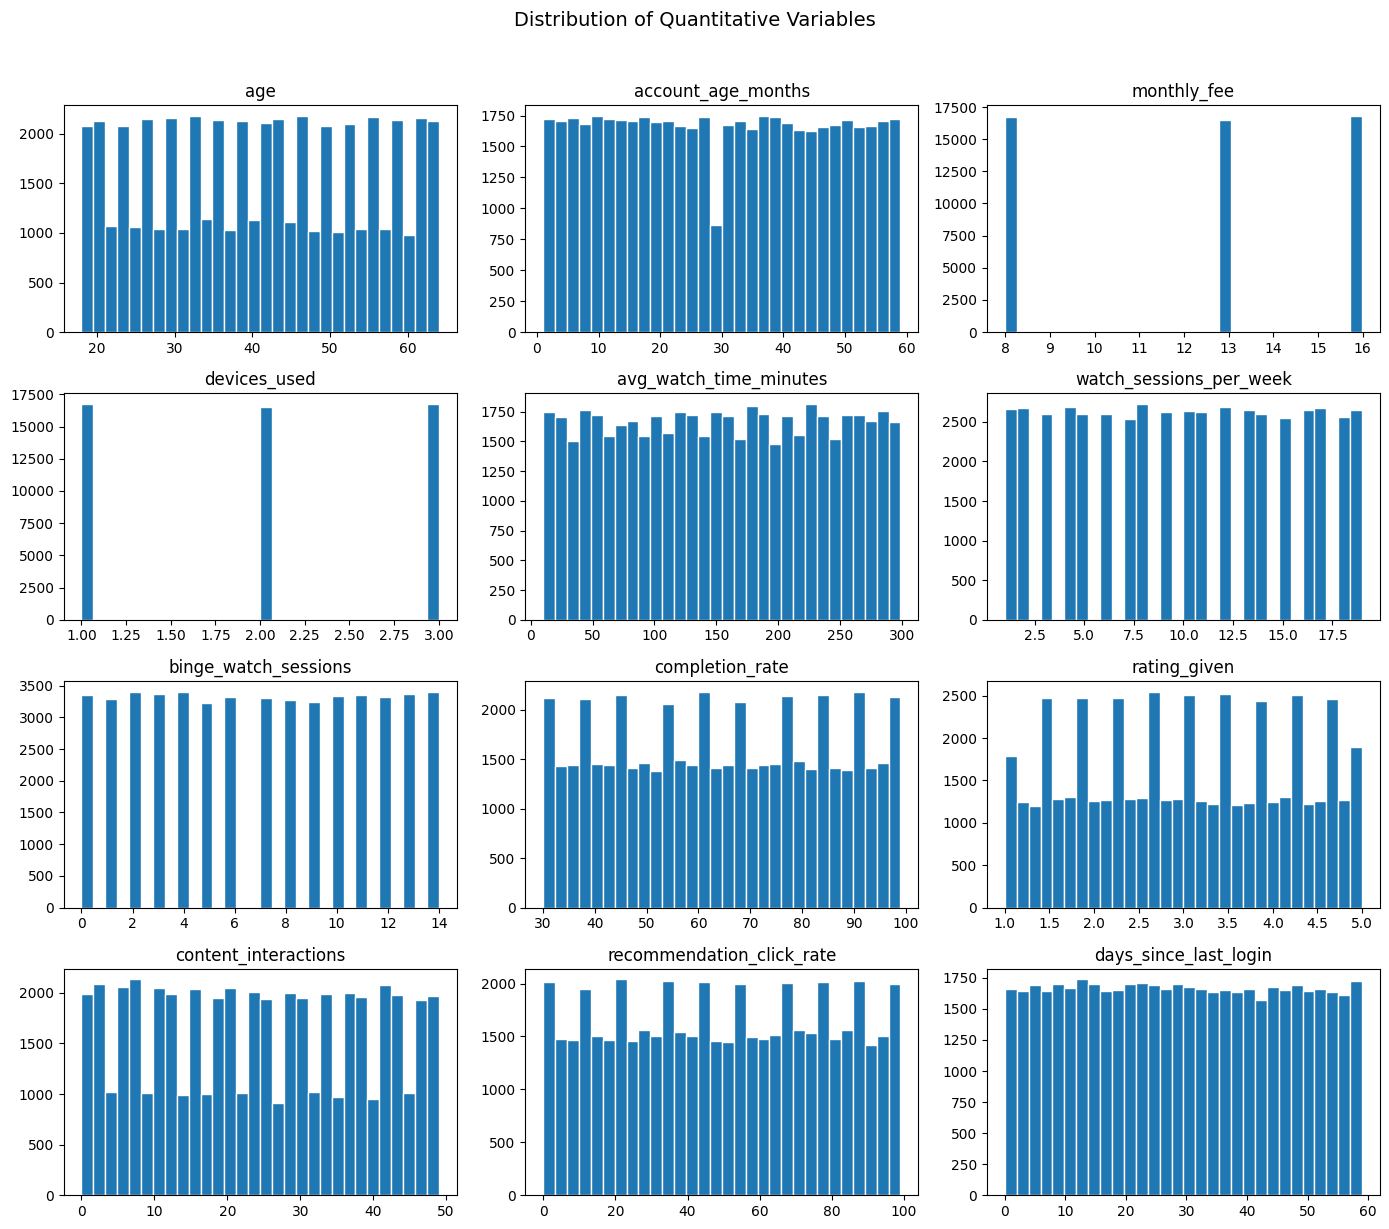

In [8]:
#visualization of quantitative variables
quant_vars = [
    'age', 'account_age_months', 'monthly_fee', 'devices_used',
    'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions',
    'completion_rate', 'rating_given', 'content_interactions',
    'recommendation_click_rate', 'days_since_last_login'
]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    axes[i].hist(netflix_data[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('histogram_panel.png', dpi=150, bbox_inches='tight')
plt.show()

Engagement-related variables such as avg_watch_time_minutes and recommendation_click_rate exhibit relatively high standard deviations, indicating substantial variation in user behavior that may be informative for predicting churn status. The close alignment between means and medians across most variables suggest approximately symmetric distributions with limited skew. There is no apparent skew across any of the quantitative variable distributions, reflecting the synthetic nature of the dataset. However, variables monthly_fee, devices_used, and rating_given exhibit discrete distributions and may warrant treatment as ordinal features prior to modeling.

In [9]:
#categorical variable summary
netflix_data.describe(include = ['object'])

<positron-console-cell-9>:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


,user_id,gender,country,subscription_type,payment_method,primary_device,favorite_genre,churned
count,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,3,10,3,4,4,8,2
top,U100000,Female,Brazil,Standard,PayPal,Mobile,Documentary,No
freq,1,16759,5116,19931,12539,12585,6352,40036


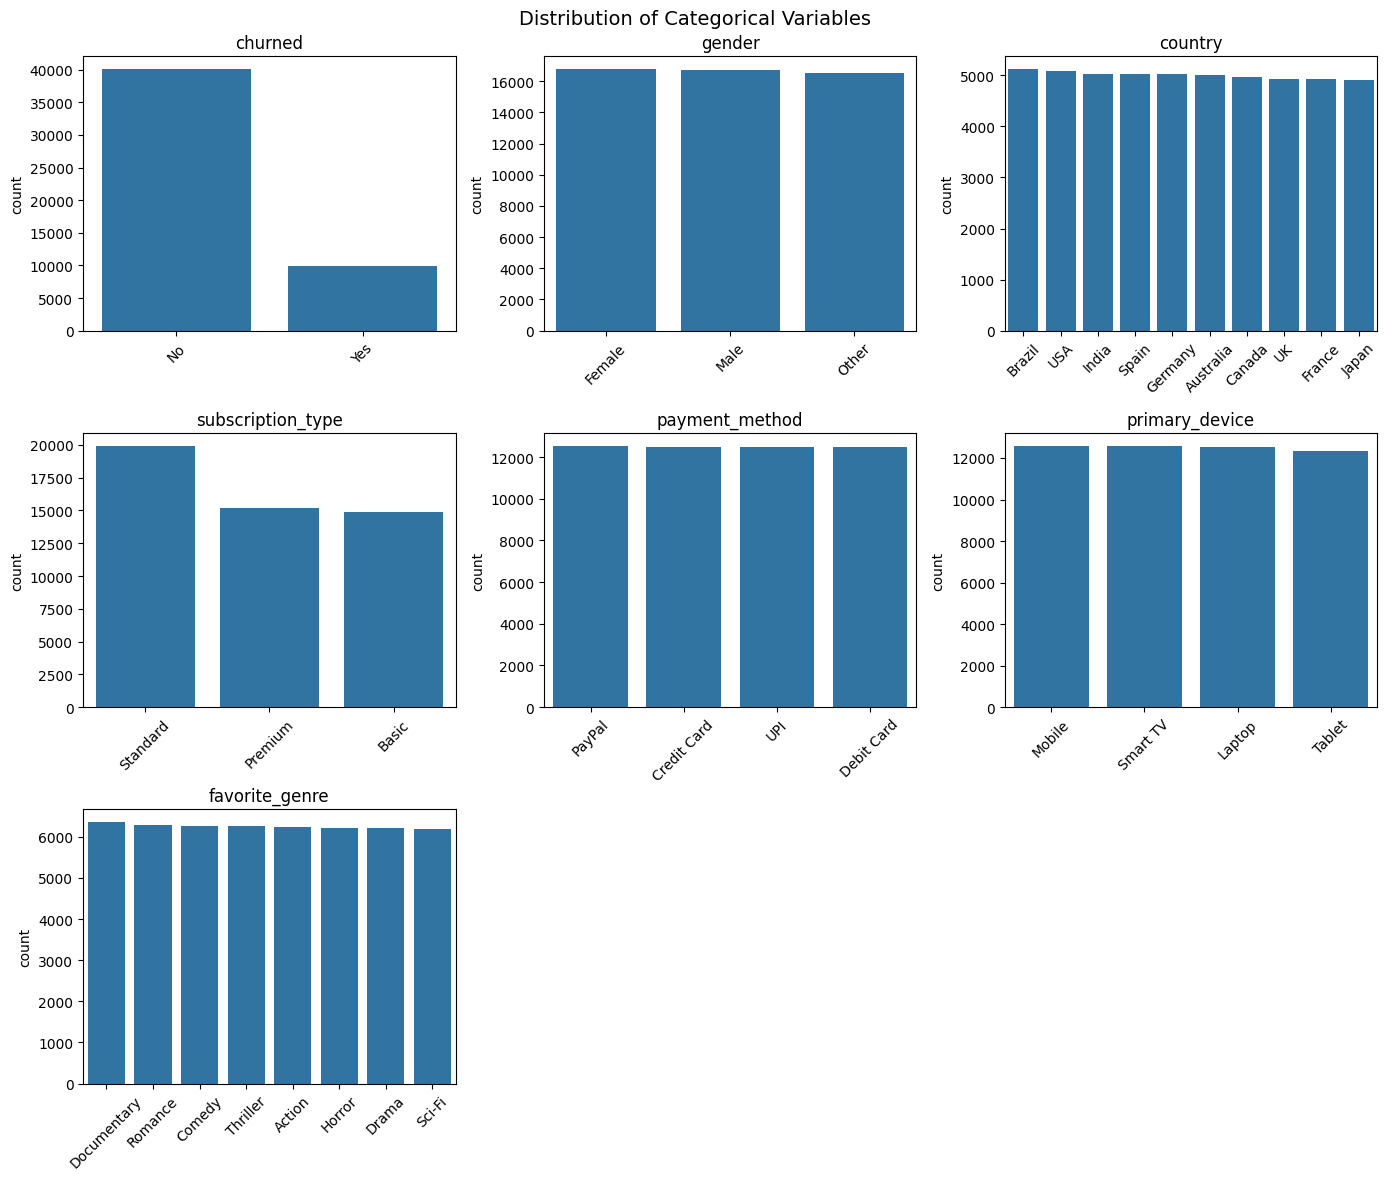

In [10]:
cat_vars = [
    'churned', 'gender', 'country', 'subscription_type',
    'payment_method', 'primary_device', 'favorite_genre'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = netflix_data[var].value_counts().index  # sort bars by frequency
    sns.countplot(data=netflix_data, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# hide the 2 unused subplots (7 variables, 9 slots)
for j in range(len(cat_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_panel.png', dpi=150, bbox_inches='tight')
plt.show()

The target variable, churn status, is imbalanced. 80% of users did not churn while only 20% did. This imbalance will inform the choice of evaluation metric and will require strategies such as class weighting during modeling. Beyond the target variable, subscription type skews toward standard plans, while the remaining categorical variables exhibit largely uniform distributions across their categories, consistent with the synthetic nature of the dataset mentioned earlier.

In [11]:
#sweetviz to show visual of associations between variables
project_report = sv.analyze(netflix_data)
project_report.show_html('project_report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report project_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


![Associations between variables](netflix_data_associations.png)

Very little to no association between the variables.

## Data preprocessing for modeling

In [5]:
netflix_data.dtypes

user_id                          str
age                            int64
gender                           str
country                          str
account_age_months             int64
subscription_type                str
monthly_fee                  float64
payment_method                   str
primary_device                   str
devices_used                   int64
favorite_genre                   str
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                          str
dtype: object

In [26]:
# drop user ID
netflix_data = netflix_data.drop('user_id', axis=1)

# encode churn status
netflix_data['churned'] = (netflix_data['churned'] == 'Yes').astype(int)

num_cols = ['age', 'account_age_months', 'monthly_fee', 'devices_used', 
            'avg_watch_time_minutes', 'watch_sessions_per_week', 
            'binge_watch_sessions', 'completion_rate', 'rating_given', 
            'content_interactions', 'recommendation_click_rate', 
            'days_since_last_login']

cat_cols = ['gender', 'country', 'subscription_type', 
            'payment_method', 'primary_device', 'favorite_genre']

y = netflix_data['churned']

# one-hot encode categorical variables
X = pd.concat([
    netflix_data[num_cols],
    pd.get_dummies(netflix_data[cat_cols], drop_first=True).astype(int)
], axis=1)

# train + test + validation split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=321)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, stratify=y_train_full, test_size=0.2, random_state=321)

# scaled variables for logistic regression and multilayer perceptron
scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols]   = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])


## Baseline modeling

In [27]:
#model definitions

#Random Forest
rf_model = RandomForestClassifier(random_state=321, class_weight='balanced', n_jobs = -1)

#Extra Trees
et_model = ExtraTreesClassifier(class_weight='balanced', random_state=321, n_jobs = -1)

#XGBoost
xgb_model = XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                    random_state=321, eval_metric='auc')

#LightGBM
lgbm_model = LGBMClassifier(is_unbalance=True, random_state=321, n_jobs=-1, verbose = -1)

#Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=321)

#Naive Bayes
nb_model = GaussianNB()

#MLP

#set random seed
tf.random.set_seed(321)

#construct the model
input_dim = X_train_scaled.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="netflix_churn_mlp")

#compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

In [28]:
#define cross validation method
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [29]:
#evaluate models - Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train, y_train)

y_proba = rf_model.predict_proba(X_val)[:,1]
print("Random Forest Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, rf_model.predict(X_val)))

[0.47889878 0.49927519 0.49861395 0.48111954
 0.48255204]
0.48809189887036675
0.008939760379906682
Random Forest Baseline ROC AUC: 0.5091362747674996
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6406
           1       0.00      0.00      0.00      1594

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.64      0.80      0.71      8000



/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [32]:
#evaluate models - Extra Trees
cv_scores_et = cross_val_score(et_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_et)
print(cv_scores_et.mean())
print(cv_scores_et.std())

et_model.fit(X_train, y_train)

y_proba = et_model.predict_proba(X_val)[:,1]
print("Extra Trees Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, et_model.predict(X_val)))

[0.487364   0.49257092 0.50688253 0.4906933  0.49163462]
0.49382907257389447
0.006759015373052275
Extra Trees Baseline ROC AUC: 0.5097185786067093
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6406
           1       0.00      0.00      0.00      1594

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.64      0.80      0.71      8000



In [34]:
#evaluate models - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train, y_train)

y_proba = xgb_model.predict_proba(X_val)[:,1]
print("XGBoost Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, xgb_model.predict(X_val)))

[0.4774454  0.50721281 0.49251489 0.47858533 0.51853307]
0.49485830092440775
0.016041438185347014
XGBoost Baseline ROC AUC: 0.4986623464278901
              precision    recall  f1-score   support

           0       0.80      0.72      0.76      6406
           1       0.20      0.28      0.23      1594

    accuracy                           0.64      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.68      0.64      0.66      8000



In [35]:
#evaluate models - LGBM
cv_scores_lgbm = cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lgbm)
print(cv_scores_lgbm.mean())
print(cv_scores_lgbm.std())

lgbm_model.fit(X_train, y_train)

y_proba = lgbm_model.predict_proba(X_val)[:,1]
print("LightGBM Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lgbm_model.predict(X_val)))

[0.48653916 0.47948587 0.49794854 0.47430213 0.49200727]
0.4860565936200654
0.00846644707803788
LightGBM Baseline ROC AUC: 0.5054445311034079
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      6406
           1       0.21      0.39      0.27      1594

    accuracy                           0.58      8000
   macro avg       0.51      0.51      0.49      8000
weighted avg       0.69      0.58      0.62      8000



In [36]:
##evaluate models - Logistic Regression
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lr)
print(cv_scores_lr.mean())
print(cv_scores_lr.std())

lr_model.fit(X_train_scaled, y_train)

y_proba = lr_model.predict_proba(X_val_scaled)[:,1]
print("Logistic Regression Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lr_model.predict(X_val_scaled)))

[0.48867429 0.49942936 0.50555562 0.48719594 0.51042005]
0.4982550523669215
0.009129722555796794
Logistic Regression Baseline ROC AUC: 0.5057272608685944
              precision    recall  f1-score   support

           0       0.80      0.50      0.61      6406
           1       0.20      0.51      0.29      1594

    accuracy                           0.50      8000
   macro avg       0.50      0.50      0.45      8000
weighted avg       0.68      0.50      0.55      8000



In [37]:
#evaluate models - Naive Bayes
cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_nb)
print(cv_scores_nb.mean())
print(cv_scores_nb.std())

nb_model.fit(X_train, y_train)

y_proba = nb_model.predict_proba(X_val)[:,1]
print("Naive Bayes Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, nb_model.predict(X_val)))

[0.48903448 0.49998425 0.51639552 0.48243895 0.50698789]
0.498968218594936
0.012173366780094879
Naive Bayes Baseline ROC AUC: 0.49815731095886817
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6406
           1       0.00      0.00      0.00      1594

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.64      0.80      0.71      8000



/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [40]:
#evaluate models - MLP
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

y_proba = model.predict(X_val_scaled).flatten()
y_pred = (y_proba > 0.5).astype(int)
print("Keras MLP Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred, zero_division=0))

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - auc: 0.4993 - loss: 0.6954 - val_auc: 0.4915 - val_loss: 0.6777
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - auc: 0.5244 - loss: 0.6923 - val_auc: 0.5007 - val_loss: 0.6791
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - auc: 0.5394 - loss: 0.6907 - val_auc: 0.5023 - val_loss: 0.6768
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - auc: 0.5552 - loss: 0.6883 - val_auc: 0.4980 - val_loss: 0.6823
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - auc: 0.5704 - loss: 0.6855 - val_auc: 0.4991 - val_loss: 0.6873
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - auc: 0.5854 - loss: 0.6820 - val_auc: 0.4991 - val_loss: 0.6903
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - auc: 0.6007 - loss: 0.6780 - val_auc: 0.5009 - val_loss: 0.6938
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - auc: 0.6128 - loss: 0.6738 - val_auc: 0.4989 - val_loss: 0.6960
Epoch 9/20
1000/1000 ━━━

**Quick insights:**

All model ROC AUC scores close to 0.5 -> the dataset has no predictive signal?